In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (r2_score, mean_absolute_error,
                             mean_squared_error, mean_absolute_percentage_error)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
import warnings
import os # Import the os module
warnings.filterwarnings('ignore')


In [2]:
# ── 1. LOAD & CLEAN DATA ──────────────────────────────────────────────────
df = pd.read_csv("/content/final_dataset.csv")
df = df.dropna()
df = df[df['PM2.5'] < 999]
df = df[df['PM10']  < 999]
df = df.reset_index(drop=True)
print(f"Dataset shape: {df.shape}")

# ── 2. SHARED TRAIN/TEST SPLIT (random_state=42, same as RF/GB) ────────────────
X = df.drop("AQI", axis=1)
y = df["AQI"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Keep the TEST indices so LSTM/GRU can be evaluated on the EXACT same rows
test_indices = y_test.index.to_numpy()   # shape (292,)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Dataset shape: (1459, 12)
Train size: 1167, Test size: 292


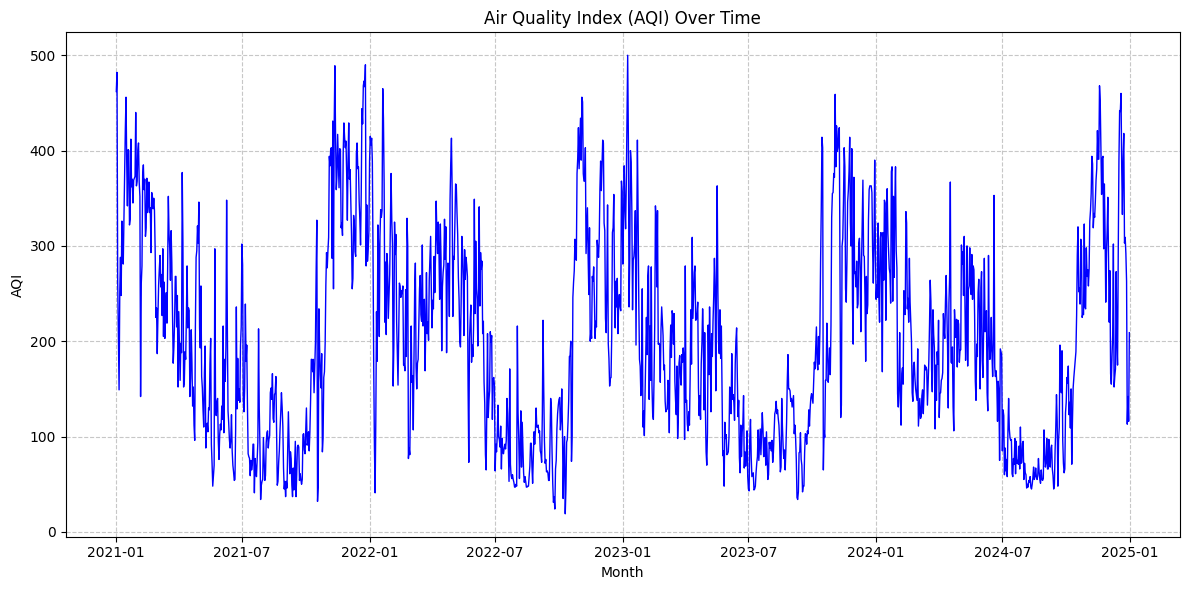

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Combine Year, Month, and Date into a single datetime column
# Rename columns temporarily to match pd.to_datetime expected names (year, month, day)
df_temp = df.rename(columns={'Date': 'day', 'Month': 'month', 'Year': 'year'})
df['Datetime'] = pd.to_datetime(df_temp[['year', 'month', 'day']])

# Sort the data by date
df = df.sort_values(by='Datetime')

# 1. AQI Trend Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Datetime'], df['AQI'], color='blue', linewidth=1)
plt.title('Air Quality Index (AQI) Over Time')
plt.xlabel('Month')
plt.ylabel('AQI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('aqi_trend.png')
plt.show()

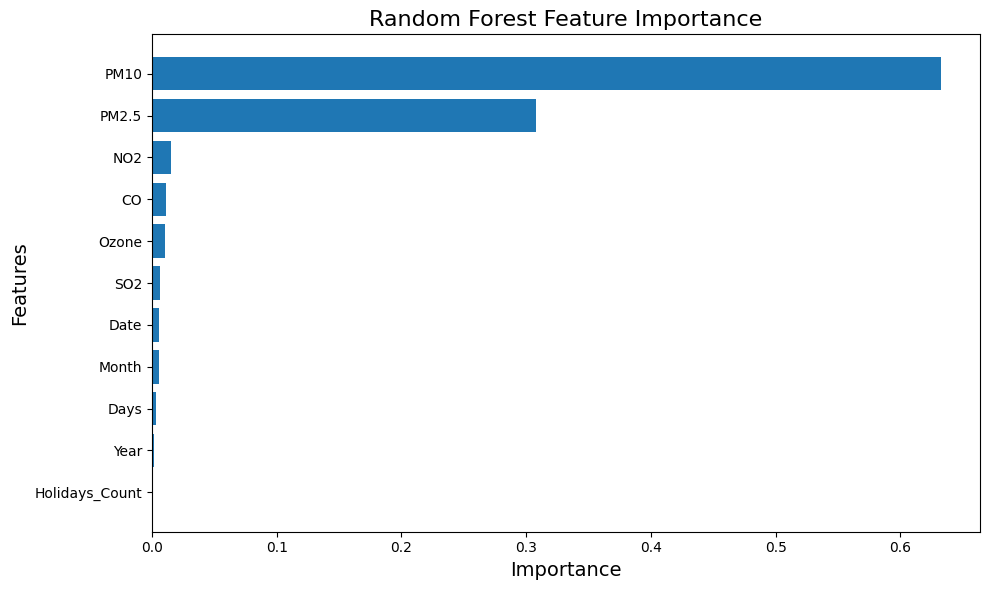

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature importance
importances = rf_model.feature_importances_
features = X.columns

# Create DataFrame for better visualization
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort by importance
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.title("Random Forest Feature Importance", fontsize=16)
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

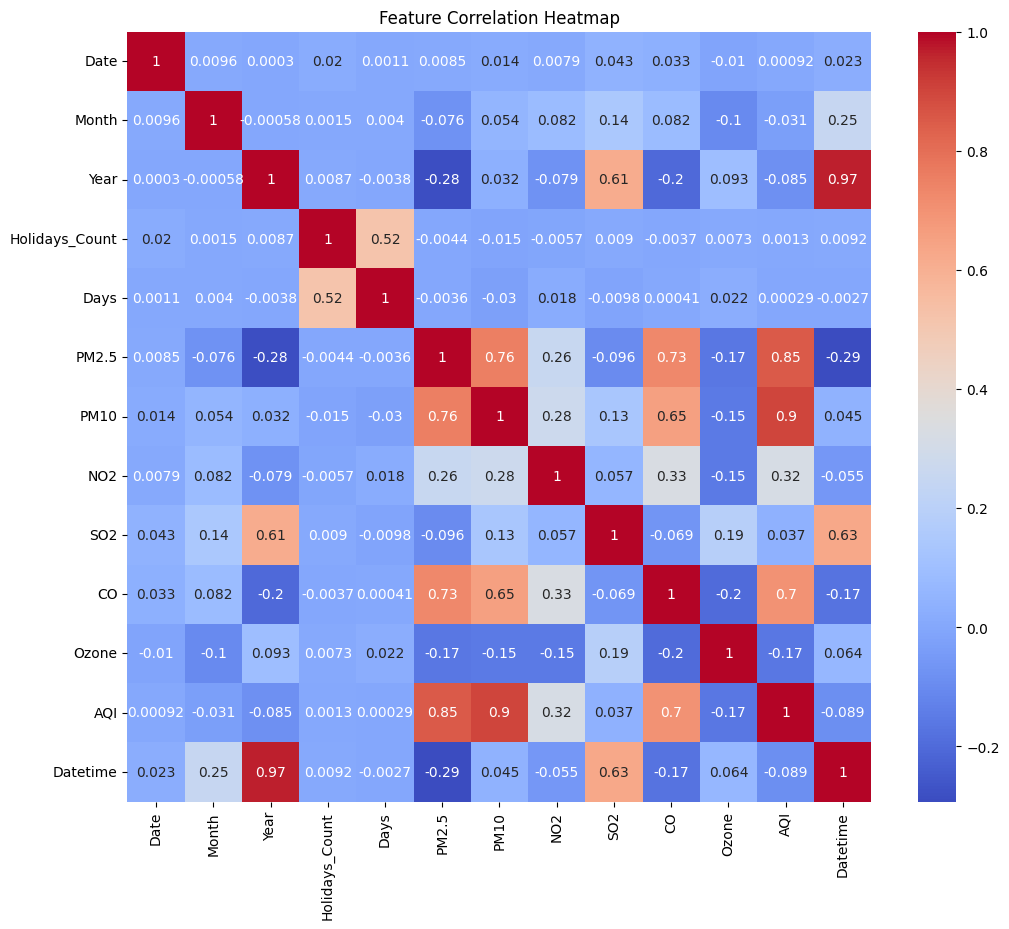

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

In [5]:
# ── 3. RANDOM FOREST ──────────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)



In [6]:
r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100

print("R2 Score:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("MAPE:", mape_rf)


R2 Score: 0.9430743306715706
MAE: 18.893732876712328
RMSE: 26.67975493946931
MAPE: 10.746405880372206


In [7]:
# ── 4. GRADIENT BOOSTING ──────────────────────────────────────────────────
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

r2_gb   = r2_score(y_test, y_pred_gb)
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mape_gb = mean_absolute_percentage_error(y_test, y_pred_gb) * 100

print("R2 Score:", r2_gb)
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("MAPE:", mape_gb)

R2 Score: 0.9455438678441772
MAE: 18.290639102905967
RMSE: 26.094630947401242
MAPE: 10.54306769291444


In [8]:
# ── 5. PREPARE SEQUENCE DATA FOR LSTM / GRU ───────────────────────────────────
# KEY FIX: Build sequences over the FULL dataset (sorted by original row order).
# After predicting, we slice only the predictions that correspond to test_indices.

sequence_features = ["PM2.5","PM10","NO2","SO2","CO","Ozone",
                     "Date","Month","Year","Holidays_Count","Days","AQI"]
data_multi = df[sequence_features].values          # (1459, 12)

scaler_multi = MinMaxScaler()
data_scaled  = scaler_multi.fit_transform(data_multi)

aqi_col_idx = sequence_features.index("AQI")      # = 11
TIME_STEPS  = 10

def create_sequences_full(data, time_steps=10):
    """
    Returns X_seq[i] = rows [i … i+time_steps-1]  →  predict row i+time_steps
    The 'original_index' array maps each sequence to its TARGET row index in df.
    """
    X_seq, y_seq, orig_idx = [], [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i : i + time_steps, :])
        y_seq.append(data[i + time_steps, aqi_col_idx])
        orig_idx.append(i + time_steps)             # target row in df
    return np.array(X_seq), np.array(y_seq).reshape(-1, 1), np.array(orig_idx)

X_seq_all, y_seq_all, orig_idx_all = create_sequences_full(data_scaled, TIME_STEPS)
print(f"\nTotal sequences: {X_seq_all.shape[0]}")  # 1449



Total sequences: 1449


In [9]:
# ── 6. ALIGN: find sequences whose TARGET row is in test_indices ───────────────────
# For TRAINING  : use sequences whose target row is in X_train.index
train_mask = np.isin(orig_idx_all, X_train.index)
test_mask  = np.isin(orig_idx_all, test_indices)

X_train_seq = X_seq_all[train_mask]
y_train_seq = y_seq_all[train_mask]
X_test_seq  = X_seq_all[test_mask]
y_test_seq  = y_seq_all[test_mask]
seq_test_orig_idx = orig_idx_all[test_mask]  # original row positions for test

print(f"Seq train: {X_train_seq.shape[0]}, Seq test: {X_test_seq.shape[0]}")

def inverse_aqi(scaled_vals):
    dummy = np.zeros((len(scaled_vals), len(sequence_features)))
    dummy[:, aqi_col_idx] = scaled_vals.flatten()
    return scaler_multi.inverse_transform(dummy)[:, aqi_col_idx].reshape(-1, 1)

y_test_seq_inv = inverse_aqi(y_test_seq)   # ground truth for seq models

Seq train: 1157, Seq test: 292


In [10]:
# ── 7. LSTM ──────────────────────────────────────────────────
model_lstm = Sequential([
    LSTM(50, activation='relu',
         input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
print("\n=== Training LSTM ===")
model_lstm.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, verbose=1)

y_pred_lstm_scaled = model_lstm.predict(X_test_seq)
y_pred_lstm_inv    = inverse_aqi(y_pred_lstm_scaled)




=== Training LSTM ===
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0579
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0176
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0155
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0144
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0137
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0131
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0124
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0121
Epoch 9/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0117
Epoch 10/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0112
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [11]:
r2_lstm   = r2_score(y_test_seq_inv, y_pred_lstm_inv)
mae_lstm  = mean_absolute_error(y_test_seq_inv, y_pred_lstm_inv)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq_inv, y_pred_lstm_inv))
mape_lstm = mean_absolute_percentage_error(y_test_seq_inv, y_pred_lstm_inv) * 100
print("R2 Score:", r2_lstm)
print("MAE:", mae_lstm)
print("RMSE:", rmse_lstm)
print("MAPE:", mape_lstm)

R2 Score: 0.7791764762117481
MAE: 40.20742362075524
RMSE: 52.547303063377925
MAPE: 24.215059902853493


In [12]:
# ── 8. GRU ──────────────────────────────────────────────────
model_gru = Sequential([
    GRU(50, activation='relu',
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse')
print("\n=== Training GRU ===")
model_gru.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, verbose=1)

y_pred_gru_scaled = model_gru.predict(X_test_seq)
y_pred_gru_inv    = inverse_aqi(y_pred_gru_scaled)




=== Training GRU ===
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0604
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0202
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0140
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0124
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0118
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0117
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0112
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0107
Epoch 9/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0104
Epoch 10/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0103
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


In [13]:
r2_gru   = r2_score(y_test_seq_inv, y_pred_gru_inv)
mae_gru  = mean_absolute_error(y_test_seq_inv, y_pred_gru_inv)
rmse_gru = np.sqrt(mean_squared_error(y_test_seq_inv, y_pred_gru_inv))
mape_gru = mean_absolute_percentage_error(y_test_seq_inv, y_pred_gru_inv) * 100

print("R2 Score:", r2_gru)
print("MAE:", mae_gru)
print("RMSE:", rmse_gru)
print("MAPE:", mape_gru)

R2 Score: 0.807854858896112
MAE: 37.34760473788499
RMSE: 49.016519095651105
MAPE: 23.491736820829555


In [14]:
# ── 9. SORT ALL PREDICTIONS BY ORIGINAL ROW INDEX (same x-axis order) ───────────────────
# This makes every model's actual/predicted arrays share the same x-axis order.
sort_order = np.argsort(test_indices)           # RF/GB sort
actual_rf_sorted   = y_test.values[sort_order]
pred_rf_sorted     = y_pred_rf[sort_order]
pred_gb_sorted     = y_pred_gb[sort_order]

seq_sort_order     = np.argsort(seq_test_orig_idx)   # LSTM/GRU sort
actual_seq_sorted  = y_test_seq_inv.flatten()[seq_sort_order]
pred_lstm_sorted   = y_pred_lstm_inv.flatten()[seq_sort_order]
pred_gru_sorted    = y_pred_gru_inv.flatten()[seq_sort_order]

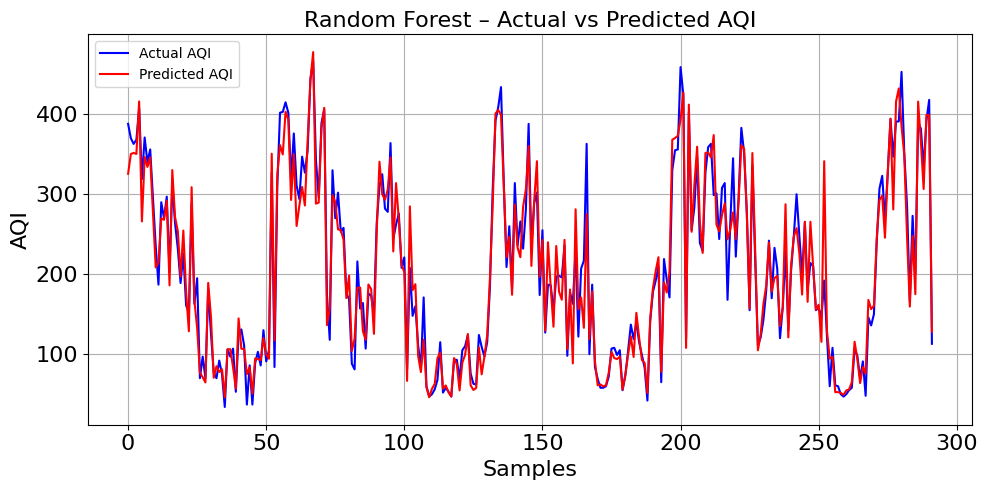

In [15]:
# ── RF Plot ─────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(actual_rf_sorted, label="Actual AQI",    color='blue')
plt.plot(pred_rf_sorted, label="Predicted AQI", color='red')
plt.title("Random Forest – Actual vs Predicted AQI", fontsize=16)
plt.xlabel("Samples", fontsize=16)
plt.ylabel("AQI",     fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend()
plt.grid()
plt.tight_layout()

output_dir = "/content/"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f"{output_dir}RF_AQI.png", dpi=600)
plt.show()

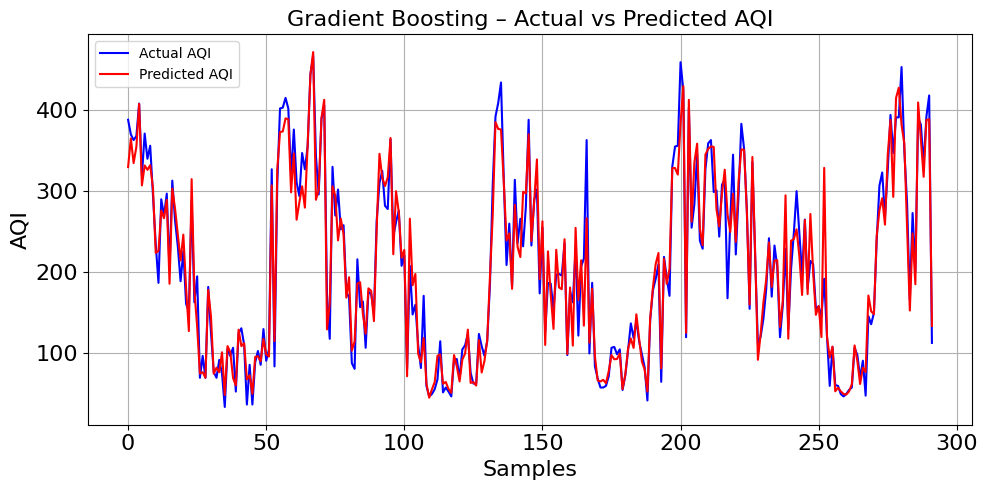

In [16]:
# ── GB Plot ─────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(actual_rf_sorted, label="Actual AQI",    color='blue')
plt.plot(pred_gb_sorted, label="Predicted AQI", color='red')
plt.title("Gradient Boosting – Actual vs Predicted AQI", fontsize=16)
plt.xlabel("Samples", fontsize=16)
plt.ylabel("AQI",     fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend()
plt.grid()
plt.tight_layout()

output_dir = "/content/"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f"{output_dir}GB_AQI.png", dpi=600)
plt.show()



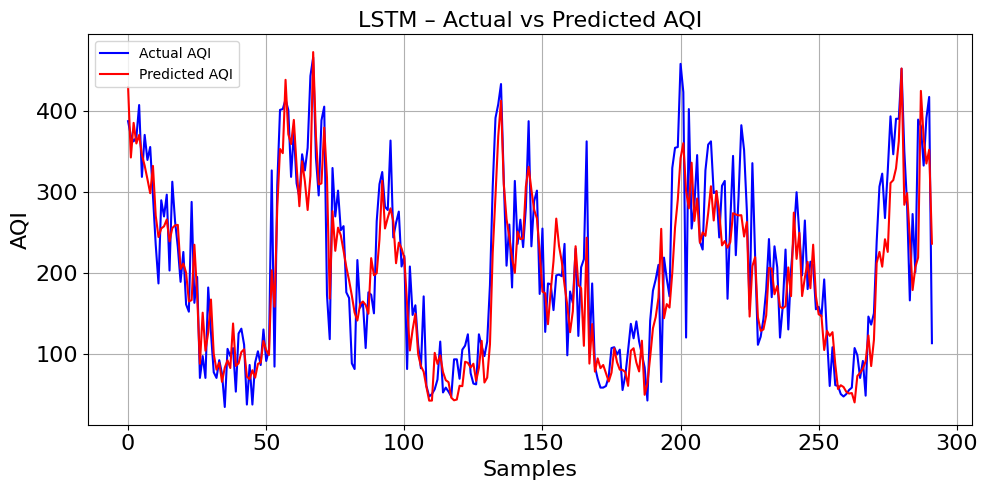

In [17]:
# ── LSTM Plot ─────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(actual_seq_sorted, label="Actual AQI",    color='blue')
plt.plot(pred_lstm_sorted, label="Predicted AQI", color='red')
plt.title("LSTM – Actual vs Predicted AQI", fontsize=16)
plt.xlabel("Samples", fontsize=16)
plt.ylabel("AQI",     fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend()
plt.grid()
plt.tight_layout()

output_dir = "/content/"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f"{output_dir}LSTM_AQI.png", dpi=600)
plt.show()


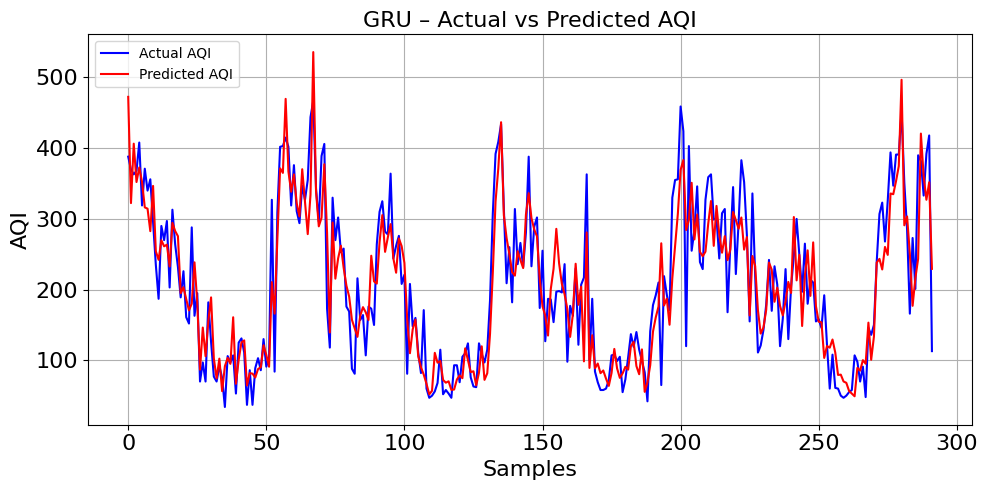

In [18]:
# ── GRU Plot ─────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(actual_seq_sorted, label="Actual AQI",    color='blue')
plt.plot(pred_gru_sorted, label="Predicted AQI", color='red')
plt.title("GRU – Actual vs Predicted AQI", fontsize=16)
plt.xlabel("Samples", fontsize=16)
plt.ylabel("AQI",     fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend()
plt.grid()
plt.tight_layout()

output_dir = "/content/"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f"{output_dir}GRU_AQI.png", dpi=600)
plt.show()


In [19]:
# Store results manually (replace values with your outputs)
results = {
    "Model": ["Random Forest", "LSTM", "GRU", "Gradient Boosting"],
    "R2": [r2_rf, r2_lstm , r2_gru , r2_gb],
    "MAE": [mae_rf, mae_lstm, mae_gru, mae_gb],
    "RMSE": [rmse_rf, rmse_lstm, rmse_gru, rmse_gb],
    "MAPE": [mape_rf, mape_lstm, mape_gru, mape_gb]
}

df_results = pd.DataFrame(results)

print(df_results)

               Model        R2        MAE       RMSE       MAPE
0      Random Forest  0.943074  18.893733  26.679755  10.746406
1               LSTM  0.779176  40.207424  52.547303  24.215060
2                GRU  0.807855  37.347605  49.016519  23.491737
3  Gradient Boosting  0.945544  18.290639  26.094631  10.543068


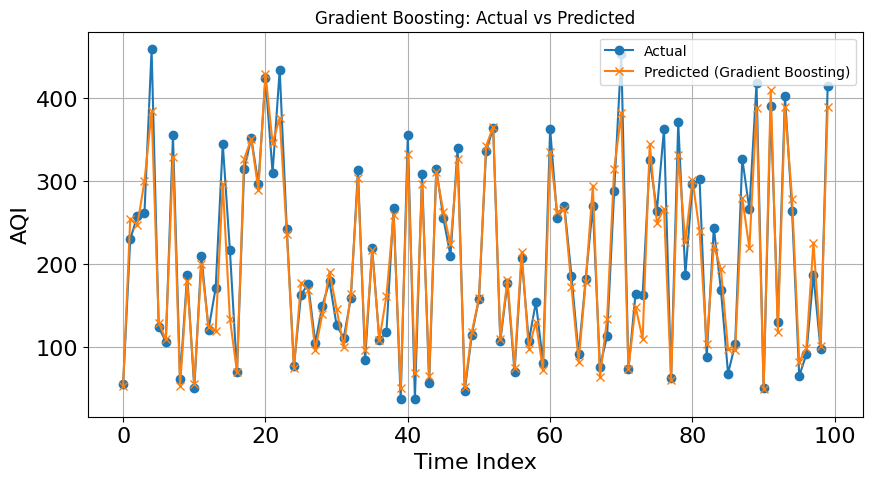

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy if needed
y_test_arr = np.array(y_test)
y_pred_gb_arr = np.array(y_pred_gb)

# Select only first 100 samples
n = 100
y_test_100 = y_test_arr[:n]
y_pred_gb_100 = y_pred_gb_arr[:n]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(y_test_100, label='Actual', marker='o')
plt.plot(y_pred_gb_100, label='Predicted (Gradient Boosting)', marker='x')

plt.title('Gradient Boosting: Actual vs Predicted')
plt.xlabel('Time Index',fontsize=16)
plt.ylabel('AQI',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc='upper right')
plt.grid(True)

plt.show()